# Module Imports

In [1]:
import scipy.io as sio
import pandas as pd
import numpy as np
import os
import torch
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

if project_root not in sys.path:

    sys.path.insert(0, project_root)

print("Project root:", project_root)

print(sys.path)

from data_classes.decomposition import Extract_Features
from data_classes.decomposition import Extract_Features
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
import models.classification as classify
import models.loops as loops
import models.models as models
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from torch.utils.data import DataLoader, Subset
import plotly.express as px
from IPython.display import display
import os

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    cohen_kappa_score
)

import io
import contextlib

Project root: /Users/kanwarsingh/Desktop/AI/acoustic_signal_classification
['/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification', '/opt/homebrew/Cellar/python@3.13/3.13.1/Frameworks/Python.framework/Versions/3.13/lib/python313.zip', '/opt/homebrew/Cellar/python@3.13/3.13.1/Frameworks/Python.framework/Versions/3.13/lib/python3.13', '/opt/homebrew/Cellar/python@3.13/3.13.1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload', '', '/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/venv/lib/python3.13/site-packages']


# Loading Data

In [2]:
# load & preprocess
P2_data = sio.loadmat('../../data/phase2_data_20220215.mat')
P2_samples = pd.DataFrame(P2_data['x'].T)
P2_labels  = pd.DataFrame(P2_data['y'].T, columns=['y'])
P2_df = pd.concat([P2_samples, P2_labels], axis=1)
bad_indices = [
    100,303,496,507,609,706,909,1011,1113,1271,1373,1475,1577,1679,1781,1883,2085,2287,
    2389,2489,2789,2891,2895,2995,3096,3497,3767,3997,4099,4201,4499,4699,5199,5301,
    5302,5500,7688,7690,7691,7692,7696,7702,7704,7708,7715,7723,7727,7810,7841,7870,
    7888,7936,7941,7965,7997,8061,8080,8081,8095,8098,8124,8125,8126,8127,8128,8132,
    8156,8157,8158,8159,8160,8161,8215,8261,8302,8310,8322,8395,8425,8477,8478,8479,
    8483,8487,8491,8496,8527,8563,8587,8642,8743,8848,
    0,94,98,102,203,403,505,607,611,708,809,1009,1111,1171,1273,1473,1575,1579,1635,
    1660,1674,1681,1881,1983,1985,2087,2088,2187,2246,2387,2589,2689,2791,2893,3196,
    3455,3495,3696,3798,3999,4199,4701,4748,4749,4798,4999,5201,5209,5244,5245,5255,
    5924,5945,5977,6128,6135,6229,6271,6299,6377,6383,6388,6389,6678,6760,6903,6906,
    6935,6936,7430,7582,7694,7698,7699,7700,7706,7710,7713,7717,7718,7777,7778,7856,
    7872,7939,7943,7960,7984,7999,8046,8048,8059,8063,8064,8068,8078,8083,8084,8085,
    8093,8165,8166,8191,8308,8366,8397,8398,8481,8485,8489,8493,8494,8498,8544,8565,
    8640,8692,8798,8902
]

P2_df = P2_df.drop(index=bad_indices, errors='ignore')
P2_df = P2_df.dropna()

shuffled_df = P2_df.sample(frac=1, random_state=42).reset_index(drop=True)
P2_df_X = shuffled_df.iloc[:, :-1]
P2_df_Y = shuffled_df.iloc[:, -1]

In [3]:
P2_raw = Extract_Features(P2_df_X, P2_df_Y, feature='raw')
print(P2_raw.get_samples().shape, P2_raw.get_labels().shape)

(8229, 4800) (8229,)


## Data Distribution

### Full Dataset Distribution

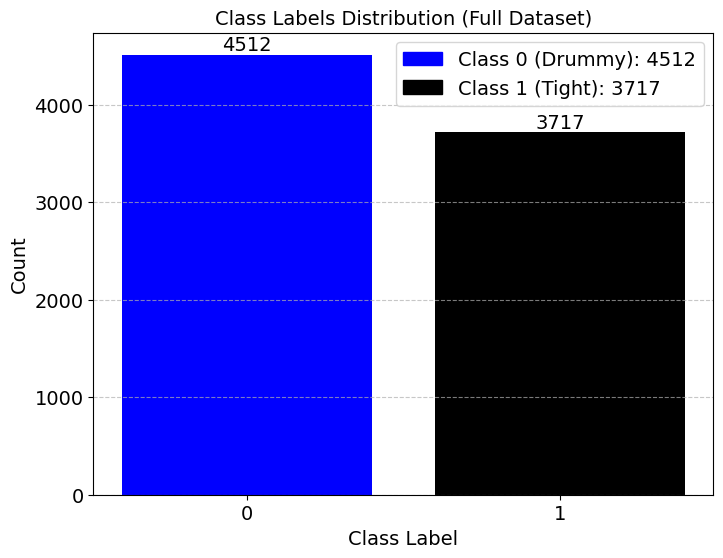

In [42]:
label_counts = P2_df_Y.value_counts().sort_index()

plt.figure(figsize=(8, 6))

colors = ['blue' if x == 0 else 'black' for x in label_counts.index]
bars = plt.bar(label_counts.index.astype(int), label_counts.values, color=colors)

plt.xlabel('Class Label', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Class Labels Distribution (Full Dataset)', fontsize=14)
plt.xticks(label_counts.index.astype(int), fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# actual count on top of each bar
for bar, count in zip(bars, label_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(count),
        ha='center',
        va='bottom',
        fontsize=14
    )

# legend with actual counts
legend_elements = [
    Patch(facecolor='blue', edgecolor='blue', label=f'Class 0 (Drummy): {label_counts.get(0, 0)}'),
    Patch(facecolor='black', edgecolor='black', label=f'Class 1 (Tight): {label_counts.get(1, 0)}')
]
plt.legend(handles=legend_elements, fontsize=14)

plt.show()

### Train, Test, Val Distribution for Epoch cutoff

In [17]:
idx_all = np.arange(len(P2_raw))
y_all = np.array([P2_raw[i][1] for i in idx_all])

# 80% training, 20% temporary validation/test set
train_idx, val_test_idx = train_test_split(
    idx_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all

)

# Split the remaining 20% equally: 10% validation, 10% test

val_idx, test_idx = train_test_split(
    val_test_idx,
    test_size=0.5,
    random_state=42,
    stratify=y_all[val_test_idx]

)

In [11]:
# distribution of class labels in train, validation, and test sets
train_labels = y_all[train_val_idx]
val_labels = y_all[val_idx]
test_labels = y_all[test_idx]

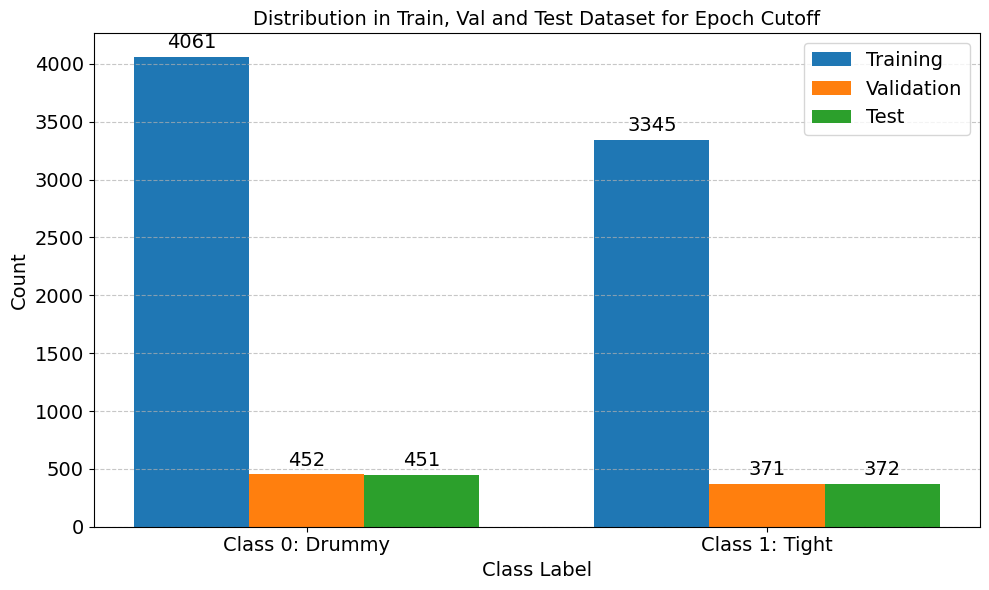

In [40]:
train_classes, train_counts = np.unique(train_labels, return_counts=True)
val_classes, val_counts = np.unique(val_labels, return_counts=True)
test_classes, test_counts = np.unique(test_labels, return_counts=True)

train_count_dict = dict(zip(train_classes, train_counts))
val_count_dict = dict(zip(val_classes, val_counts))
test_count_dict = dict(zip(test_classes, test_counts))

class_labels = [0, 1]

train_class_counts = [train_count_dict.get(0, 0), train_count_dict.get(1, 0)]
val_class_counts = [val_count_dict.get(0, 0), val_count_dict.get(1, 0)]
test_class_counts = [test_count_dict.get(0, 0), test_count_dict.get(1, 0)]

x = np.arange(len(class_labels))

bar_width = 0.25

plt.figure(figsize=(10, 6))
train_bars = plt.bar(x - bar_width, train_class_counts, width=bar_width, label="Training")
val_bars = plt.bar(x, val_class_counts, width=bar_width, label="Validation")
test_bars = plt.bar(x + bar_width, test_class_counts, width=bar_width, label="Test")

plt.xlabel("Class Label", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution in Train, Val and Test Dataset for Epoch Cutoff", fontsize=14)
plt.xticks(x, ["Class 0: Drummy", "Class 1: Tight"], fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)

all_counts = train_class_counts + val_class_counts + test_class_counts
text_offset = max(all_counts) * 0.01

for bars in [train_bars, val_bars, test_bars]:
    for bar in bars:
        count = int(bar.get_height())
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + text_offset, str(count), ha="center", va="bottom", fontsize=14)

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


### Train and Test Distribution for Model Evaluation

In [30]:
idx_all = np.arange(len(P2_raw))
y_all = np.array([P2_raw[i][1] for i in idx_all])

train_idx, test_idx = train_test_split(
    idx_all,
    test_size=0.1,
    random_state=42,
    stratify=y_all
)

In [31]:
train_labels = y_all[train_idx]
test_labels = y_all[test_idx]

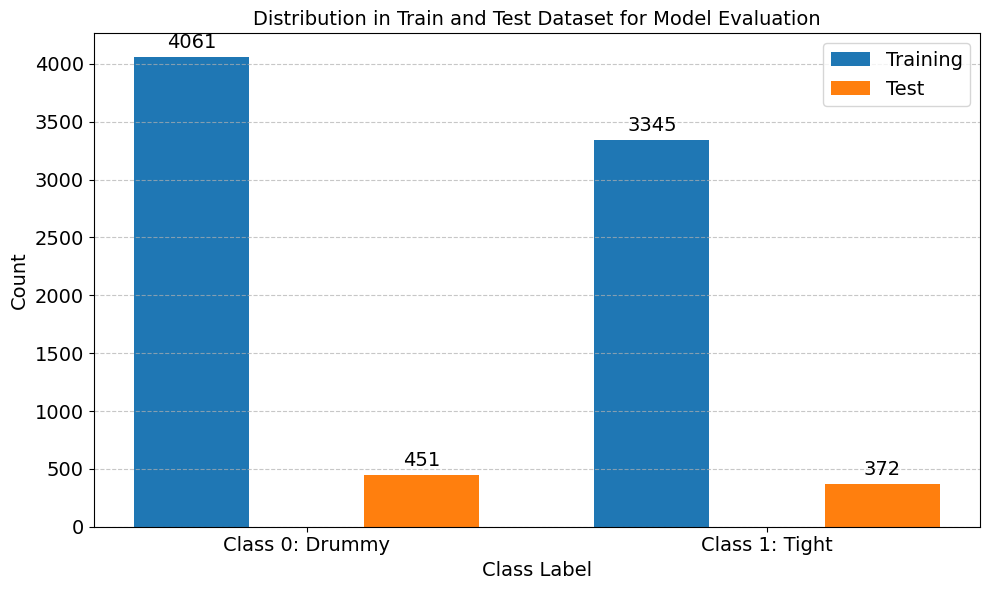

In [41]:
train_classes, train_counts = np.unique(train_labels, return_counts=True)
test_classes, test_counts = np.unique(test_labels, return_counts=True)

train_count_dict = dict(zip(train_classes, train_counts))
test_count_dict = dict(zip(test_classes, test_counts))

class_labels = [0, 1]

train_class_counts = [train_count_dict.get(0, 0), train_count_dict.get(1, 0)]
test_class_counts = [test_count_dict.get(0, 0), test_count_dict.get(1, 0)]

x = np.arange(len(class_labels))

bar_width = 0.25

plt.figure(figsize=(10, 6))
train_bars = plt.bar(x - bar_width, train_class_counts, width=bar_width, label="Training")
test_bars = plt.bar(x + bar_width, test_class_counts, width=bar_width, label="Test")

plt.xlabel("Class Label", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution in Train and Test Dataset for Model Evaluation", fontsize=14)
plt.xticks(x, ["Class 0: Drummy", "Class 1: Tight"], fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)

all_counts = train_class_counts + test_class_counts
text_offset = max(all_counts) * 0.01

for bars in [train_bars, test_bars]:
    for bar in bars:
        count = int(bar.get_height())
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + text_offset, str(count), ha="center", va="bottom", fontsize=14)

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


## Prepare ROC Dataframe

In [ ]:
roc_df = pd.DataFrame(columns=[
    "model_name",
    "model",
    "ev_pct",
    "hidden",
    "accuracy",
    "roc_auc",
    "fpr",
    "tpr",
    "roc_thresholds",
    "cohen_kappa"
])

roc_df

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds,cohen_kappa


# Classical Experiments